In [1]:
import pandas as pd

# Load dataset
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv("data_banknote_authentication.txt", header=None, names=columns)

# First five samples
print("First Five Samples")
print(df.head())

# Dataset dimensions
print("\nDataset Shape:")
print(df.shape)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

First Five Samples
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Shape:
(1372, 5)

Missing Values:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive Statistics:
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250 

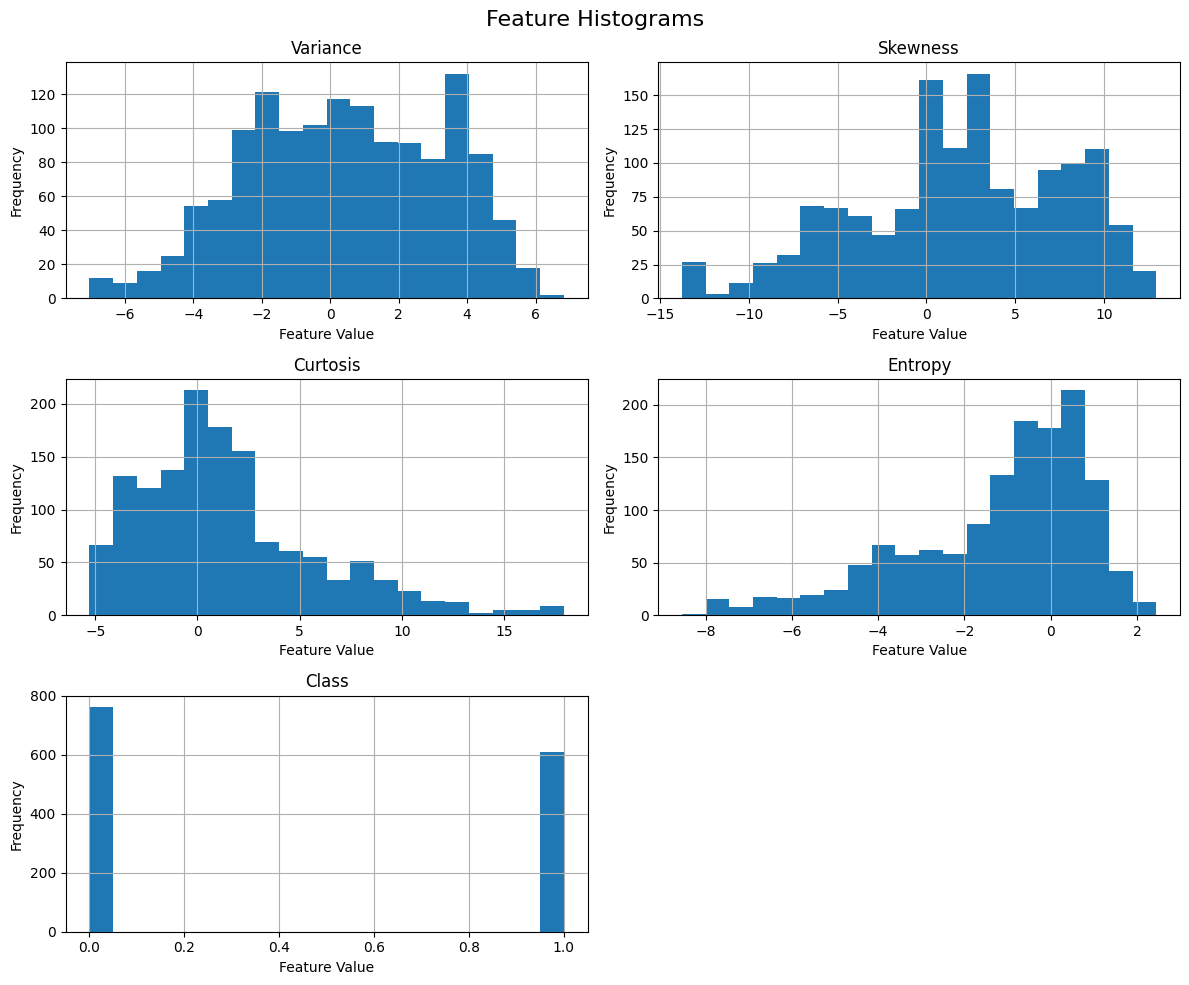

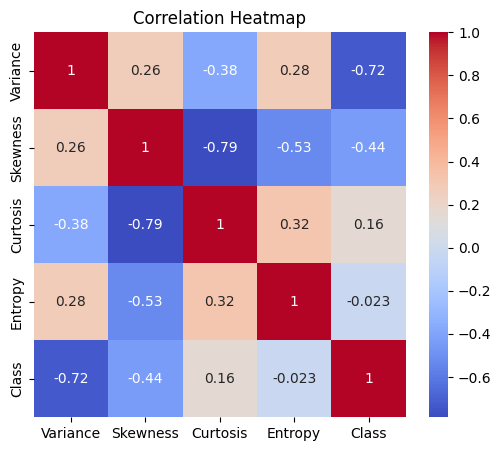

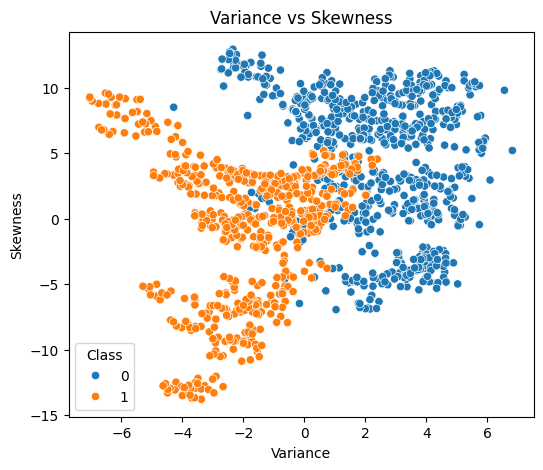

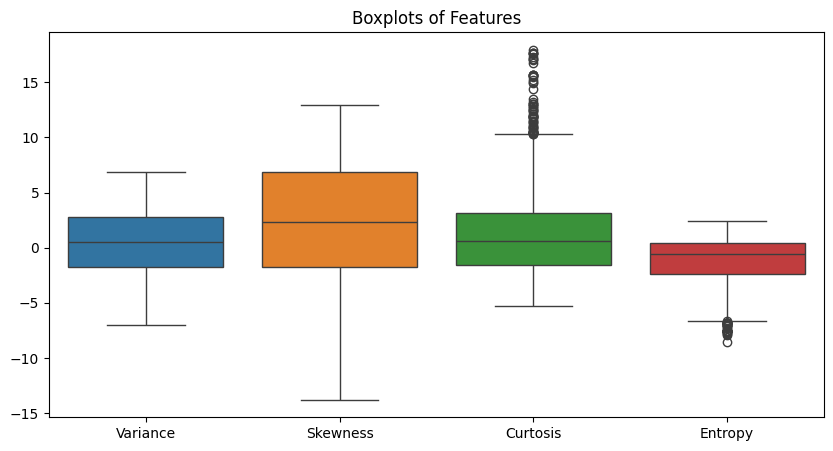

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
axes = df.hist(figsize=(12,10), bins=20)

plt.suptitle("Feature Histograms", fontsize=16)
for ax in axes.flatten():
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter Plot
plt.figure(figsize=(6,5))
sns.scatterplot(x='Variance', y='Skewness', hue='Class', data=df)
plt.title("Variance vs Skewness")
plt.show()

# Boxplots
plt.figure(figsize=(10,5))
sns.boxplot(data=df.iloc[:,:-1])
plt.title("Boxplots of Features")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Features and Target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Convert labels from {0,1} to {-1,1}
y = [1 if label == 1 else -1 for label in y]

# Normalize
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1097
Testing Samples: 275


In [27]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs

    # Weight Initialization
    def initialize(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    # Step Activation Function
    def activation(self, x):
        return 1 if x >= 0 else -1

    # Forward Propagation
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        predictions = np.array([self.activation(i) for i in linear_output])
        return predictions

    # Perceptron Learning Rule
    def fit(self, X, y):

      self.initialize(X.shape[1])

      # Store history
      self.errors = []
      self.weight_history = []
      self.bias_history = []

      for epoch in range(self.epochs):

        errors = 0

        for xi, target in zip(X, y):

            linear_output = np.dot(xi, self.weights) + self.bias
            prediction = self.activation(linear_output)

            # Standard Perceptron Learning Rule
            if prediction != target:

                self.weights += self.lr * target * xi
                self.bias += self.lr * target

                errors += 1

        self.errors.append(errors)
        self.weight_history.append(self.weights.copy())
        self.bias_history.append(self.bias)

        print(f"Epoch {epoch+1}")
        print("Misclassified Samples:", errors)
        print("Updated Weights:", self.weights)
        print("Updated Bias:", self.bias)
        print("-"*40)

In [44]:
# Create Perceptron object
model = Perceptron(learning_rate=0.1, epochs=40)

# Train
model.fit(X_train, y_train)

Epoch 1
Misclassified Samples: 166
Updated Weights: [-0.68274078 -0.38668532 -0.53190972  0.15293538]
Updated Bias: 0.7999999999999999
----------------------------------------
Epoch 2
Misclassified Samples: 88
Updated Weights: [-0.83116105 -0.61463152 -0.76878383  0.11624225]
Updated Bias: 0.9999999999999999
----------------------------------------
Epoch 3
Misclassified Samples: 57
Updated Weights: [-0.87315739 -0.65655397 -0.95930508  0.15060017]
Updated Bias: 1.0999999999999999
----------------------------------------
Epoch 4
Misclassified Samples: 51
Updated Weights: [-0.95385683 -0.79743107 -0.9285397   0.10170151]
Updated Bias: 1.2
----------------------------------------
Epoch 5
Misclassified Samples: 47
Updated Weights: [-0.97783436 -0.85640299 -1.00255103  0.05781127]
Updated Bias: 1.3
----------------------------------------
Epoch 6
Misclassified Samples: 45
Updated Weights: [-1.05811604 -0.88618353 -1.01493801  0.04330288]
Updated Bias: 1.4000000000000001
--------------------

In [45]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred, pos_label=1)

# Recall
recall = recall_score(y_test, y_pred, pos_label=1)

# F1 Score
f1 = f1_score(y_test, y_pred, pos_label=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix")
print(cm)

Accuracy : 0.9854545454545455
Precision: 1.0
Recall   : 0.968503937007874
F1 Score : 0.984

Confusion Matrix
[[148   0]
 [  4 123]]


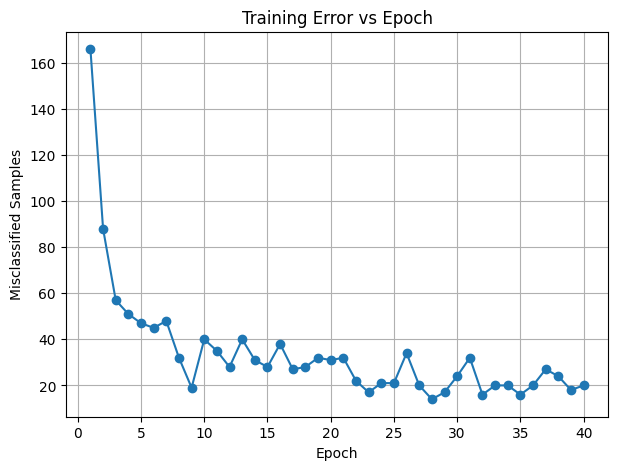

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(range(1, len(model.errors)+1), model.errors, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.grid(True)
plt.show()

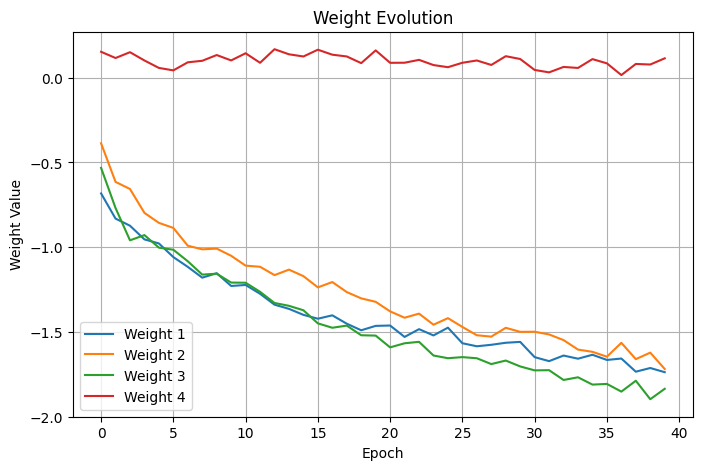

In [47]:
import numpy as np

weights = np.array(model.weight_history)

plt.figure(figsize=(8,5))

for i in range(weights.shape[1]):
    plt.plot(weights[:,i], label=f'Weight {i+1}')

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution")
plt.legend()
plt.grid(True)
plt.show()

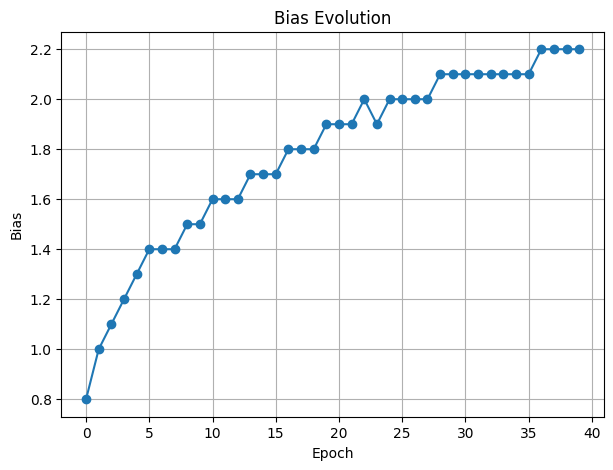

In [48]:
plt.figure(figsize=(7,5))
plt.plot(model.bias_history, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution")
plt.grid(True)
plt.show()

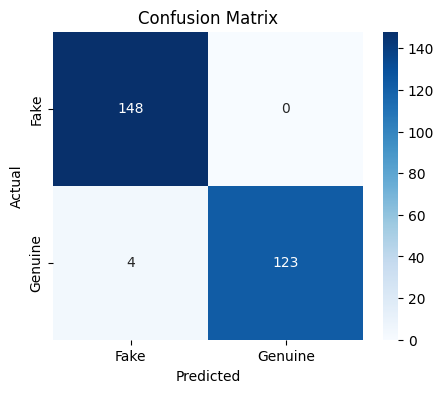

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Fake','Genuine'],
            yticklabels=['Fake','Genuine'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Epoch 1
Misclassified Samples: 166
Updated Weights: [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Updated Bias: 0.008
----------------------------------------
Epoch 2
Misclassified Samples: 88
Updated Weights: [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Updated Bias: 0.010000000000000002
----------------------------------------
Epoch 3
Misclassified Samples: 57
Updated Weights: [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Updated Bias: 0.011000000000000003
----------------------------------------
Epoch 4
Misclassified Samples: 51
Updated Weights: [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Updated Bias: 0.012000000000000004
----------------------------------------
Epoch 5
Misclassified Samples: 47
Updated Weights: [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Updated Bias: 0.013000000000000005
----------------------------------------
Epoch 6
Misclassified Samples: 45
Updated Weights: [-0.01058116 -0.00886184 -0.01014938  0.00043303]
Updated Bias: 0.014000000000

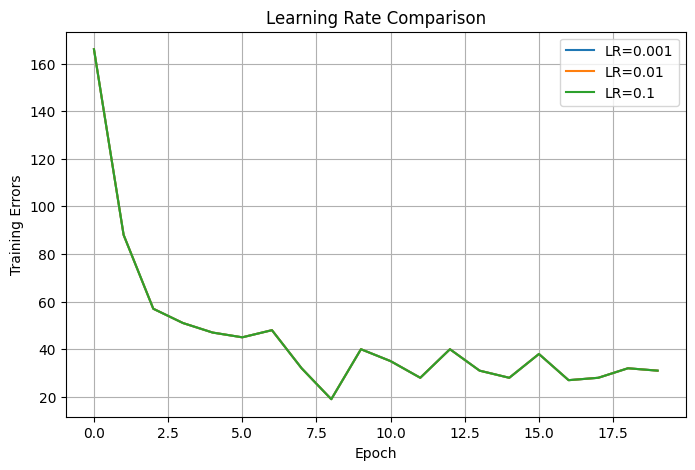

In [50]:
learning_rates = [0.001,0.01,0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    model = Perceptron(learning_rate=lr, epochs=20)
    model.fit(X_train,y_train)

    plt.plot(model.errors,label=f"LR={lr}")

plt.xlabel("Epoch")
plt.ylabel("Training Errors")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()

Epoch 1
Misclassified Samples: 3
Updated Weights: [0.0174049  0.03099496]
Updated Bias: 0.1
----------------------------------------
Epoch 2
Misclassified Samples: 2
Updated Weights: [-0.01878704  0.01098725]
Updated Bias: 0.1
----------------------------------------
Epoch 3
Misclassified Samples: 2
Updated Weights: [-0.05497898 -0.00902046]
Updated Bias: 0.1
----------------------------------------
Epoch 4
Misclassified Samples: 2
Updated Weights: [-0.09117092 -0.02902816]
Updated Bias: 0.1
----------------------------------------
Epoch 5
Misclassified Samples: 3
Updated Weights: [-0.07316343  0.0150756 ]
Updated Bias: 0.2
----------------------------------------
Epoch 6
Misclassified Samples: 4
Updated Weights: [-0.09488696 -0.00849387]
Updated Bias: 0.2
----------------------------------------
Epoch 7
Misclassified Samples: 2
Updated Weights: [-0.1310789  -0.02850157]
Updated Bias: 0.2
----------------------------------------
Epoch 8
Misclassified Samples: 2
Updated Weights: [-0.167

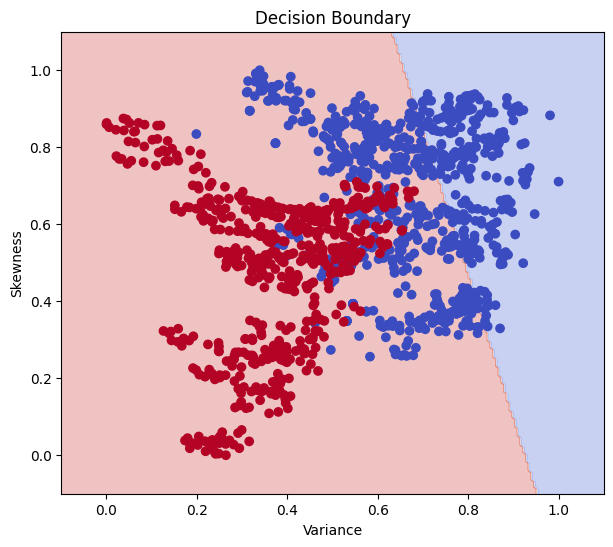

In [51]:
from sklearn.preprocessing import MinMaxScaler

X2 = df.iloc[:,0:2].values
y2 = np.array([1 if c==1 else -1 for c in df['Class']])

X2 = MinMaxScaler().fit_transform(X2)

model2 = Perceptron(learning_rate=0.1,epochs=20)
model2.fit(X2,y2)

x_min,x_max=X2[:,0].min()-0.1,X2[:,0].max()+0.1
y_min,y_max=X2[:,1].min()-0.1,X2[:,1].max()+0.1

xx,yy=np.meshgrid(np.linspace(x_min,x_max,200),
                  np.linspace(y_min,y_max,200))

Z=model2.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx,yy,Z,alpha=0.3,cmap='coolwarm')

plt.scatter(X2[:,0],X2[:,1],c=y2,cmap='coolwarm')

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Decision Boundary")
plt.show()

In [52]:
import pandas as pd

summary = pd.DataFrame({

'Metric':[
'Dataset Size',
'Train/Test Split',
'Learning Rate',
'Epochs',
'Final Weights',
'Final Bias',
'Accuracy',
'Precision',
'Recall',
'F1 Score'
],

'Value':[

len(df),
'80 : 20',
model.lr,
model.epochs,
model.weights,
model.bias,
accuracy,
precision,
recall,
f1

]

})

print(summary)

             Metric                                              Value
0      Dataset Size                                               1372
1  Train/Test Split                                            80 : 20
2     Learning Rate                                                0.1
3            Epochs                                                 20
4     Final Weights  [-1.4641164290504762, -1.322097228406682, -1.5...
5        Final Bias                                                1.9
6          Accuracy                                           0.985455
7         Precision                                                1.0
8            Recall                                           0.968504
9          F1 Score                                              0.984


In [54]:
learning_rates = [0.001, 0.01, 0.1]

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for lr in learning_rates:

    print("="*50)
    print(f"Training Perceptron with Learning Rate = {lr}")
    print("="*50)

    model = Perceptron(learning_rate=lr, epochs=40)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    results.append([lr, acc, pre, rec, f1])

Training Perceptron with Learning Rate = 0.001
Epoch 1
Misclassified Samples: 166
Updated Weights: [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Updated Bias: 0.008
----------------------------------------
Epoch 2
Misclassified Samples: 88
Updated Weights: [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Updated Bias: 0.010000000000000002
----------------------------------------
Epoch 3
Misclassified Samples: 57
Updated Weights: [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Updated Bias: 0.011000000000000003
----------------------------------------
Epoch 4
Misclassified Samples: 51
Updated Weights: [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Updated Bias: 0.012000000000000004
----------------------------------------
Epoch 5
Misclassified Samples: 47
Updated Weights: [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Updated Bias: 0.013000000000000005
----------------------------------------
Epoch 6
Misclassified Samples: 45
Updated Weights: [-0.01058116 -0.00886184 -0.010

In [56]:
import pandas as pd

comparison = pd.DataFrame(
    results,
    columns=[
        "Learning Rate",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison

,Learning Rate,Accuracy,Precision,Recall,F1 Score
0,0.001,0.985455,1.0,0.968504,0.984
1,0.010,0.985455,1.0,0.968504,0.984
2,0.100,0.985455,1.0,0.968504,0.984


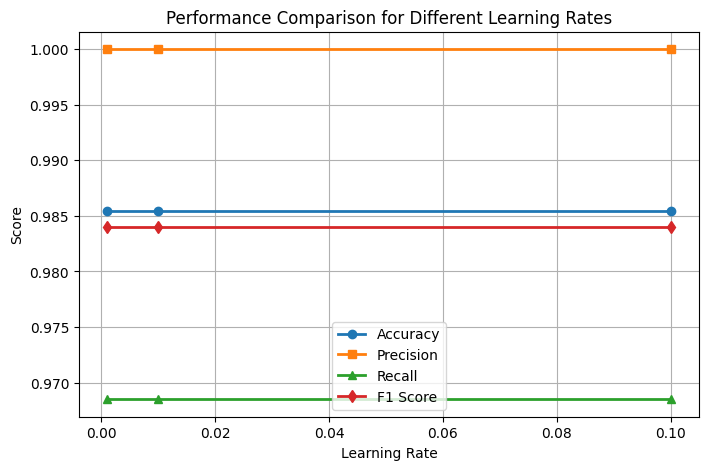

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(comparison["Learning Rate"],
         comparison["Accuracy"],
         marker='o',
         linewidth=2,
         label="Accuracy")

plt.plot(comparison["Learning Rate"],
         comparison["Precision"],
         marker='s',
         linewidth=2,
         label="Precision")

plt.plot(comparison["Learning Rate"],
         comparison["Recall"],
         marker='^',
         linewidth=2,
         label="Recall")

plt.plot(comparison["Learning Rate"],
         comparison["F1 Score"],
         marker='d',
         linewidth=2,
         label="F1 Score")

plt.xlabel("Learning Rate")
plt.ylabel("Score")
plt.title("Performance Comparison for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=40
    )

    model.fit(X_train, y_train)

    print("\nLearning Rate:", lr)
    print("Weights:", model.weights)
    print("Bias:", model.bias)

Epoch 1
Misclassified Samples: 166
Updated Weights: [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Updated Bias: 0.008
----------------------------------------
Epoch 2
Misclassified Samples: 88
Updated Weights: [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Updated Bias: 0.010000000000000002
----------------------------------------
Epoch 3
Misclassified Samples: 57
Updated Weights: [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Updated Bias: 0.011000000000000003
----------------------------------------
Epoch 4
Misclassified Samples: 51
Updated Weights: [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Updated Bias: 0.012000000000000004
----------------------------------------
Epoch 5
Misclassified Samples: 47
Updated Weights: [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Updated Bias: 0.013000000000000005
----------------------------------------
Epoch 6
Misclassified Samples: 45
Updated Weights: [-0.01058116 -0.00886184 -0.01014938  0.00043303]
Updated Bias: 0.014000000000